In [1]:
import torch
import torch.nn as nn
from tqdm import tqdm

from red import UNet3D
from qsmloader import QSMLoader
from torch.utils.data import DataLoader
from utils import plot_3d_medical_image
import matplotlib.pyplot as plt
from loss import quantile_regression_loss_fn
from scipy import io
from utils import continuous_dipole_kernel
import numpy as np

In [2]:
torch.cuda.init()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load COSMOS data

In [3]:
data = io.loadmat('F:/data/Cosmos_SNR100.mat')
chi_cosmos = data['chi_cosmos'] * data['mask_use']
mask_cosmos = data['mask_use']

data = io.loadmat('F:/data/evaluation_mask.mat')
eval_mask_cosmos = data['evaluation_mask']

In [4]:

def gen_cosmos(jump=False):
    phase = np.real(np.fft.ifftn(np.fft.fftn(chi_cosmos) * continuous_dipole_kernel(chi_cosmos.shape))) * mask_cosmos

    mag = chi_cosmos - chi_cosmos.min()
    mag = mag / mag.max()
    mag = mag * mask_cosmos

    scale = np.pi / (2 * np.max(np.abs(phase)))
    signal = mag * np.exp(1j * phase * scale)

    snr = np.random.randint(95, 105, (1,))

    signal = signal + ((1. / snr) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape)))

    phase = np.angle(signal).astype(np.float32) / scale
    phase = phase * mask_cosmos
    if jump:
        phase[80, 80, 80] = 2

    p = torch.Tensor(phase.copy()).unsqueeze(0).unsqueeze(0)
    return p

In [5]:
def eval_cosmos(recon):
    metrics = {}
    metrics['rmse'] = 100 * np.linalg.norm(recon.ravel() - chi_cosmos.ravel()) / np.linalg.norm(chi_cosmos.ravel())
    for i in range(12):
        sub_mask = eval_mask_cosmos == i
        pred = recon[sub_mask]
        gt = chi_cosmos[sub_mask]
        metrics[f'rmse_zona_{i}'] = 100 * np.linalg.norm(gt - pred) / np.linalg.norm(gt)
        metrics[f'mean_zona_{i}'] = np.mean(pred)
        metrics[f'std_zona_{i}'] = np.std(pred)
    return metrics

# Load Model

In [6]:
model = UNet3D(in_channels=1, out_channels=3)
model = model.to(device)
# model.load_state_dict(torch.load('./saved/model_epoch_48.pth', weights_only=False))
model.eval()

UNet3D(
  (enc1): ConvBlock(
    (conv): Sequential(
      (0): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (enc2): ConvBlock(
    (conv): Sequential(
      (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): L

In [7]:
p = gen_cosmos(False)
p2 = gen_cosmos(True)

In [8]:
rmse = []
rmse2 = []
for i in tqdm(range(1, 21)):

    if i < 17:
        model.load_state_dict(torch.load(f'./saved/ph_checkpoint_epoch_{i}.pth', weights_only=False)['model'])
    elif i == 17:
        model.load_state_dict(torch.load(f'./saved/ph_checkpoint_epoch_6_respaldo.pth', weights_only=False)['model'])
    elif i == 18:
        model.load_state_dict(torch.load(f'./saved/ph_checkpoint_epoch_7_respaldo.pth', weights_only=False)['model'])
    elif i == 19:
        model.load_state_dict(torch.load(f'./saved/ph_checkpoint_epoch_2_respaldo.pth', weights_only=False)['model'])
    elif i == 20:
        model.load_state_dict(torch.load(f'./saved/ph_checkpoint_epoch_5_respaldo.pth', weights_only=False)['model'])
    # elif i==11:
    #     model.load_state_dict(torch.load(f'./saved/checkpoint_epoch_8_respaldo.pth', weights_only=False)['model'])
    # elif i == 12:
    #     model.load_state_dict(torch.load(f'./saved/checkpoint_epoch_8_respaldo2.pth', weights_only=False)['model'])
    # model = model.to(device)
    model.eval()
    with torch.inference_mode():
        out = model((p).to(device)).cpu() * mask_cosmos
    gt = chi_cosmos * 1.
    pred = out[0, 1].numpy() * mask_cosmos
    m = mask_cosmos == 1
    rmse.append(100 * np.linalg.norm(pred.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))

    with torch.inference_mode():
        out = model((p2).to(device)).cpu() * mask_cosmos
    gt = chi_cosmos * 1.
    pred = out[0, 1].numpy() * mask_cosmos
    m = mask_cosmos == 1
    rmse2.append(100 * np.linalg.norm(pred.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))

100%|██████████| 20/20 [00:24<00:00,  1.21s/it]


19 19 19


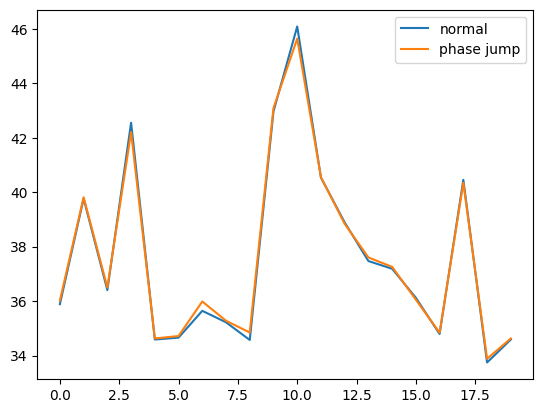

In [9]:
print((np.argmin(rmse))+1, (np.argmin(rmse2))+1, np.argmin([rmse[i] + rmse2[i] for i in range(len(rmse))])+1)
plt.figure()
plt.plot(rmse, label='normal')
plt.plot(rmse2, label='phase jump')
plt.legend()
plt.show()

In [10]:
rmse[18], rmse2[18]

(33.74379515528961, 33.88035707898138)

In [ ]:
rmse[1], rmse2[1]

In [11]:
model = UNet3D(in_channels=1, out_channels=3)
model = model.to(device)
model.load_state_dict(torch.load('./saved/ph_checkpoint_epoch_2_respaldo.pth', weights_only=False)['model'])
model.eval()

UNet3D(
  (enc1): ConvBlock(
    (conv): Sequential(
      (0): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (enc2): ConvBlock(
    (conv): Sequential(
      (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): L


# Eval model

In [12]:
def eval_model(model_in, p, mask):
    model_in.eval()
    with torch.inference_mode():
        out = model_in((p).to(device)).cpu() * mask

    output = out * 1
    lam = 1.09375
    output[:, 0, :, :, :] = torch.minimum(output[:, 0, :, :, :], output[:, 1, :, :, :])
    output[:, 2, :, :, :] = torch.maximum(output[:, 2, :, :, :], output[:, 1, :, :, :])
    upper_edge = lam * (output[:, 2, :, :, :] - output[:, 1, :, :, :]) + output[:, 1, :, :, :]
    prediction = output[:, 1, :, :, :]
    lower_edge = output[:, 1, :, :, :] - lam * (output[:, 1, :, :, :] - output[:, 0, :, :, :])

    upper_edge = upper_edge[0].numpy()
    prediction = prediction[0].numpy()
    lower_edge = lower_edge[0].numpy()
    return upper_edge, prediction, lower_edge

In [13]:
p = gen_cosmos()

In [14]:
upper_edge, prediction, lower_edge = eval_model(model, p, mask_cosmos)

In [15]:
eval_cosmos(prediction)

{'rmse': 33.22211838859263,
 'rmse_zona_0': 33.36843669916895,
 'mean_zona_0': 0.00032241087,
 'std_zona_0': 0.011961722,
 'rmse_zona_1': 14.29886684717492,
 'mean_zona_1': 0.05737404,
 'std_zona_1': 0.007134655,
 'rmse_zona_2': 11.87579654006342,
 'mean_zona_2': 0.077229485,
 'std_zona_2': 0.010960876,
 'rmse_zona_3': 10.981355855273037,
 'mean_zona_3': 0.16961524,
 'std_zona_3': 0.022615442,
 'rmse_zona_4': 10.738957756927963,
 'mean_zona_4': 0.08386361,
 'std_zona_4': 0.012415027,
 'rmse_zona_5': 13.894699552717702,
 'mean_zona_5': 0.1529935,
 'std_zona_5': 0.01800229,
 'rmse_zona_6': 12.131003081373528,
 'mean_zona_6': 0.10568632,
 'std_zona_6': 0.010496074,
 'rmse_zona_7': 20.389619570853636,
 'mean_zona_7': -0.019381506,
 'std_zona_7': 0.0033851,
 'rmse_zona_8': 22.4500479838249,
 'mean_zona_8': -0.018842524,
 'std_zona_8': 0.0032798583,
 'rmse_zona_9': 14.809926794480191,
 'mean_zona_9': -0.044969156,
 'std_zona_9': 0.0073566185,
 'rmse_zona_10': 20.551055472058113,
 'mean_zona_

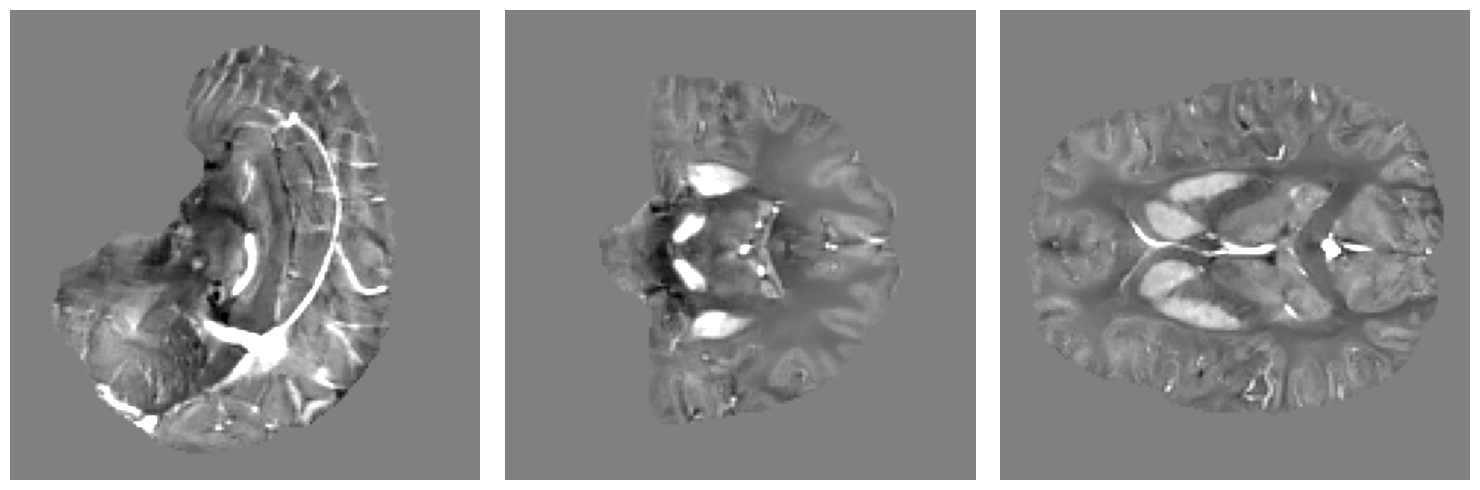

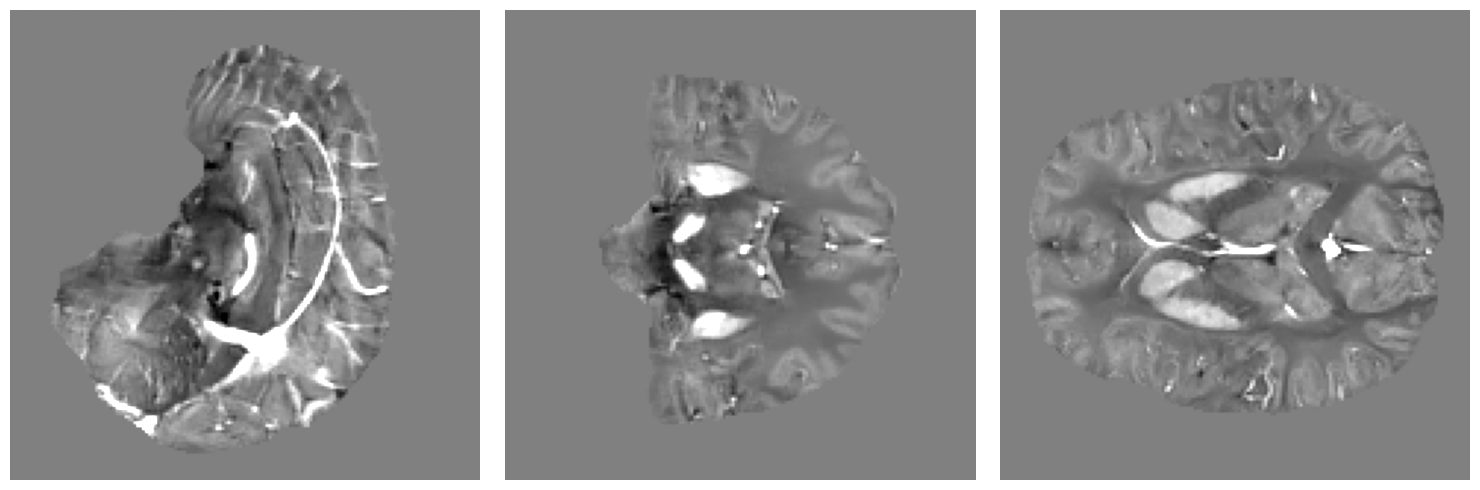

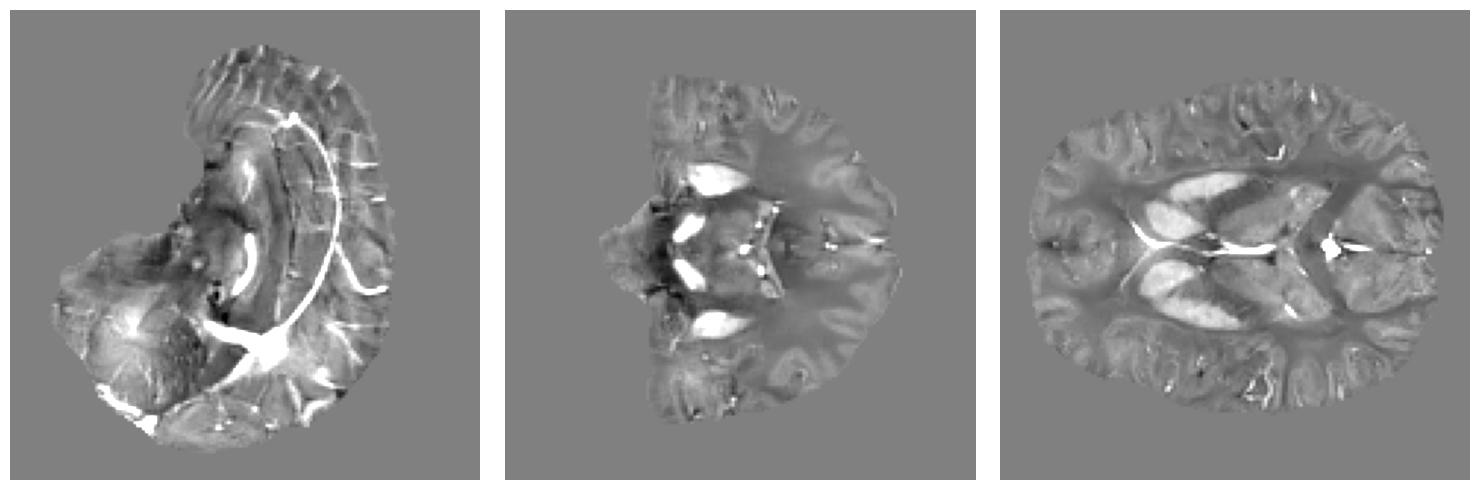

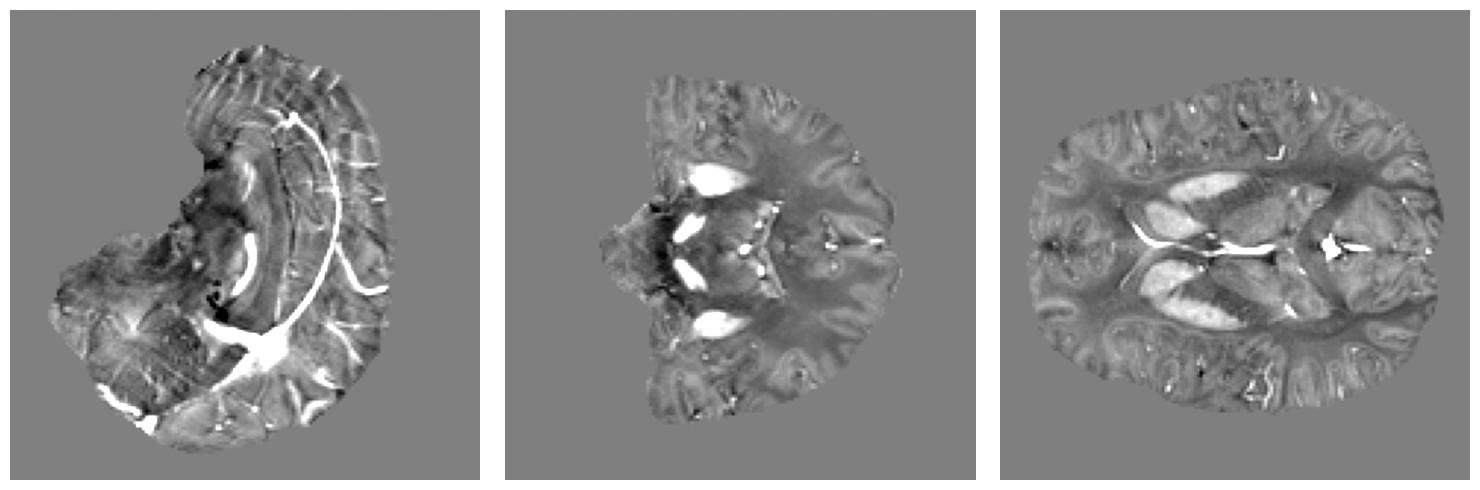

In [16]:
plot_3d_medical_image(lower_edge * mask_cosmos, rango=(-0.1, 0.1))
plot_3d_medical_image(prediction * mask_cosmos, rango=(-0.1, 0.1))
plot_3d_medical_image(upper_edge * mask_cosmos, rango=(-0.1, 0.1))
plot_3d_medical_image(chi_cosmos * mask_cosmos, rango=(-0.1, 0.1))

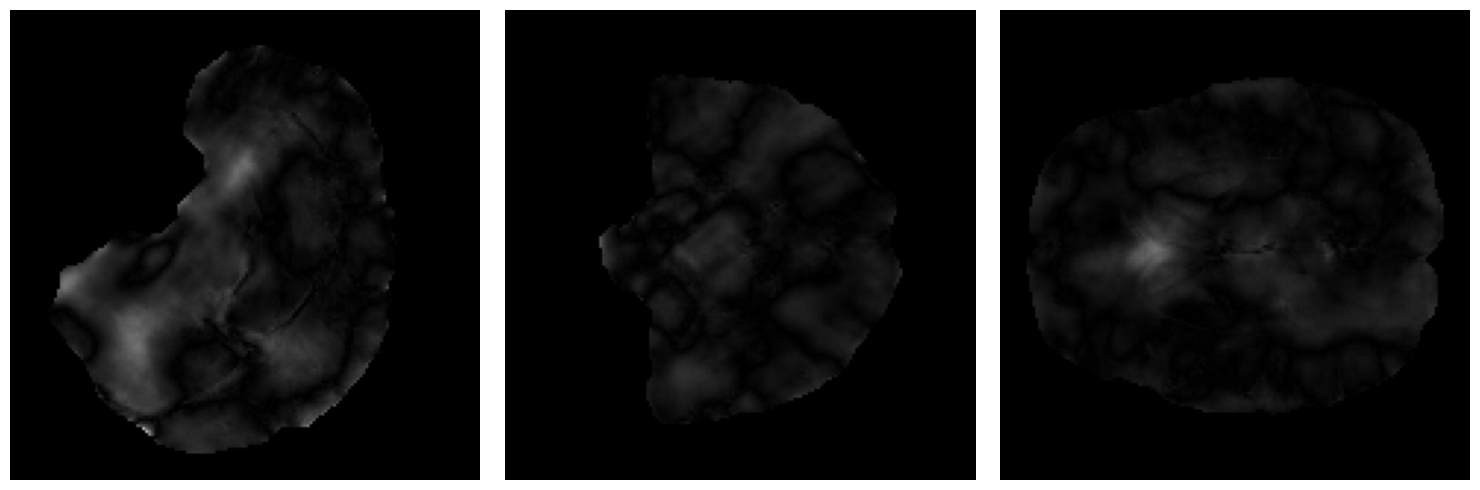

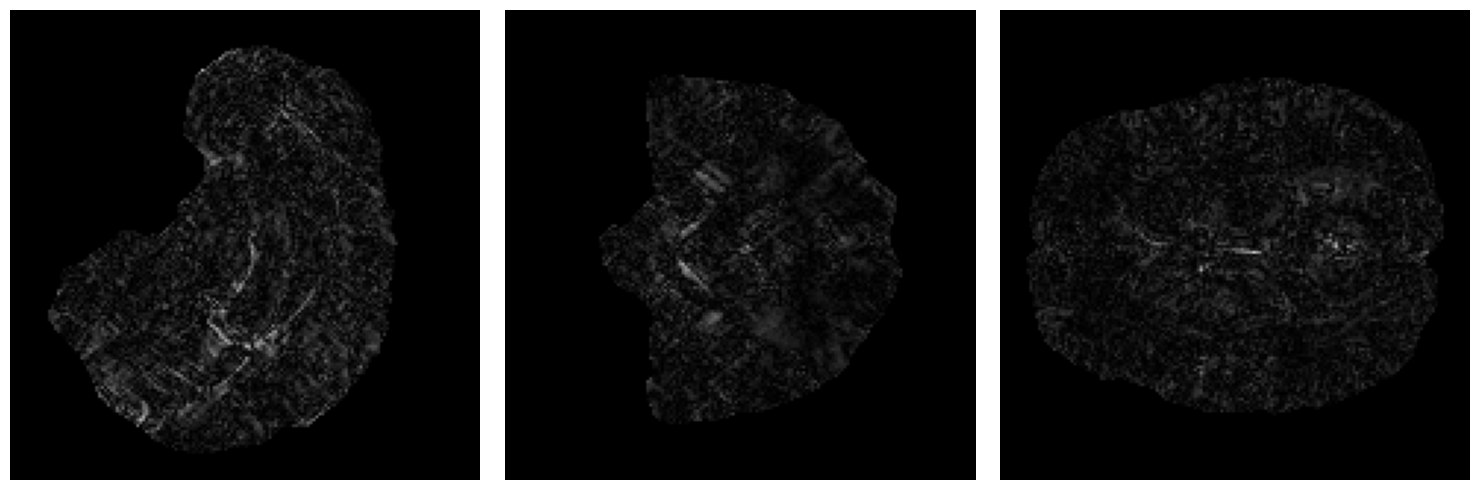

In [17]:
plot_3d_medical_image(a := (upper_edge - lower_edge) * mask_cosmos, rango=(0, 0.1))
plot_3d_medical_image(np.abs(chi_cosmos - prediction) * mask_cosmos, rango=(0, 0.1))


In [ ]:
plot_3d_medical_image(np.abs(a), rango=(0, 0.1))

In [ ]:
factor = (chi_cosmos < lower_edge) | (upper_edge < chi_cosmos)
plot_3d_medical_image(factor)

In [ ]:
factor.shape, mask_cosmos.shape

In [ ]:
np.mean(factor[mask_cosmos == 1])

In [ ]:
io.savemat('out.mat',
           {
               'upper_edge': upper_edge,
               'prediction': prediction,
               'lower_edge': lower_edge,
               'p': p,
               'mask_cosmos': mask_cosmos,
               'chi_cosmos': chi_cosmos,
           }
           )

In [ ]:
prediction.shape

In [ ]:
phaseL = np.real(np.fft.ifftn(np.fft.fftn(lower_edge) * continuous_dipole_kernel(lower_edge.shape))) * mask_cosmos
phaseU = np.real(np.fft.ifftn(np.fft.fftn(upper_edge) * continuous_dipole_kernel(upper_edge.shape))) * mask_cosmos
phase = np.real(np.fft.ifftn(np.fft.fftn(chi_cosmos) * continuous_dipole_kernel(chi_cosmos.shape))) * mask_cosmos


In [ ]:
factor = (phase < phaseL) | (phaseU < phase)
plot_3d_medical_image(factor)

In [ ]:
np.mean(factor[mask_cosmos == 1])